In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from retrieve.get_data import get_yield

In [30]:
# load weekly yields in decimal form (4.5% -> 0.045)
term       = 5
raw_yields = get_yield(term, freq="W-FRI") / 100
df_prices  = 100 / ((1 + raw_yields) ** term)

# weekly price return + carry (yield earned for holding one week)
price_ret    = df_prices.pct_change().dropna()
carry        = raw_yields.shift(1).reindex(price_ret.index) / 52
total_ret    = price_ret + carry

countries = total_ret.columns.tolist()
print(f"Assets ({len(countries)}): {countries}")
print(f"Date range: {total_ret.index.min().date()} -> {total_ret.index.max().date()} ({len(total_ret)} weeks)")

Assets (11): ['US', 'UK', 'FRA', 'GER', 'AUS', 'INDO', 'INDIA', 'JAPAN', 'SWITZ', 'BRAZIL', 'MEXICO']
Date range: 2012-02-03 -> 2026-03-13 (737 weeks)


In [31]:
# parameters
lookback           = 104      # 2-year rolling covariance window
starting_portfolio = 100_000.0
train_frac         = 0.70

In [32]:
def tangency_weights(mu, Sigma):
    """
    Long-only tangency portfolio: maximize Sharpe = w'mu / sqrt(w'Sigma w)
    subject to sum(w) = 1, w_i >= 0.

    Expected return mu uses current carry (yield/52) — forward-looking
    and stable relative to noisy historical means.
    """
    n   = len(mu)
    w0  = np.ones(n) / n

    def neg_sharpe(w):
        ret = float(w @ mu)
        vol = np.sqrt(float(w @ Sigma @ w))
        return -ret / vol if vol > 1e-12 else 0.0

    res = minimize(
        neg_sharpe,
        w0,
        method="SLSQP",
        bounds=[(0.0, 1.0)] * n,
        constraints={"type": "eq", "fun": lambda w: w.sum() - 1},
        options={"ftol": 1e-12, "maxiter": 500},
    )
    return res.x if res.success else w0

In [33]:
# train / test split
idx        = total_ret.index
split_i    = int(np.floor(train_frac * len(idx)))
split_date = idx[split_i]
start_i    = max(split_i, lookback + 1)

# walk-forward loop
portfolio  = pd.Series(np.nan, index=idx)
weights_df = pd.DataFrame(np.nan, index=idx, columns=countries)

portfolio.iloc[start_i] = starting_portfolio

for i in range(start_i, len(idx) - 1):
    end_date  = idx[i]
    next_date = idx[i + 1]

    window = total_ret.loc[:end_date].tail(lookback).dropna()
    Sigma  = window.cov().values

    # expected return = current carry (yield / 52)
    mu = raw_yields.loc[end_date].values / 52

    w = tangency_weights(mu, Sigma)
    weights_df.loc[end_date] = w

    r_next = total_ret.loc[next_date].values
    portfolio.loc[next_date] = portfolio.loc[end_date] * (1 + float(w @ r_next))

portfolio = portfolio.ffill()
print("Done.")

Done.


In [34]:
# performance metrics (OOS only)
port_oos    = portfolio.loc[split_date:].dropna()
weekly_rets = port_oos.pct_change().dropna()

# risk-free rate: US 1-year yield / 52 (same term as the portfolio)
rf_weekly   = raw_yields['US'].reindex(weekly_rets.index) / 52
excess_rets = weekly_rets - rf_weekly

sharpe    = (weekly_rets.mean() / weekly_rets.std(ddof=0)) * np.sqrt(52)
ex_sharpe = (excess_rets.mean() / excess_rets.std(ddof=0)) * np.sqrt(52)
total_r   = port_oos.iloc[-1] / port_oos.iloc[0] - 1
max_dd    = ((port_oos - port_oos.cummax()) / port_oos.cummax()).min()
hit_rate  = (weekly_rets > 0).mean()
ann_vol   = weekly_rets.std(ddof=0) * np.sqrt(52)
ann_rf    = rf_weekly.mean() * 52

print(f"Test window:              {port_oos.index.min().date()} -> {port_oos.index.max().date()}")
print(f"Starting portfolio:       ${port_oos.iloc[0]:,.2f}")
print(f"Ending portfolio:         ${port_oos.iloc[-1]:,.2f}")
print(f"Total return:             {total_r:.2%}")
print(f"Ann. Sharpe (gross):      {sharpe:.2f}")
print(f"Ann. Sharpe (excess):     {ex_sharpe:.2f}")
print(f"Ann. risk-free rate:      {ann_rf:.2%}")
print(f"Ann. Vol (realised):      {ann_vol:.2%}")
print(f"Max drawdown:             {max_dd:.2%}")
print(f"Hit rate:                 {hit_rate:.1%}")

Test window:              2021-12-17 -> 2026-03-13
Starting portfolio:       $100,000.00
Ending portfolio:         $131,776.44
Total return:             31.78%
Ann. Sharpe (gross):      2.28
Ann. Sharpe (excess):     0.97
Ann. risk-free rate:      3.76%
Ann. Vol (realised):      2.87%
Max drawdown:             -4.72%
Hit rate:                 68.3%


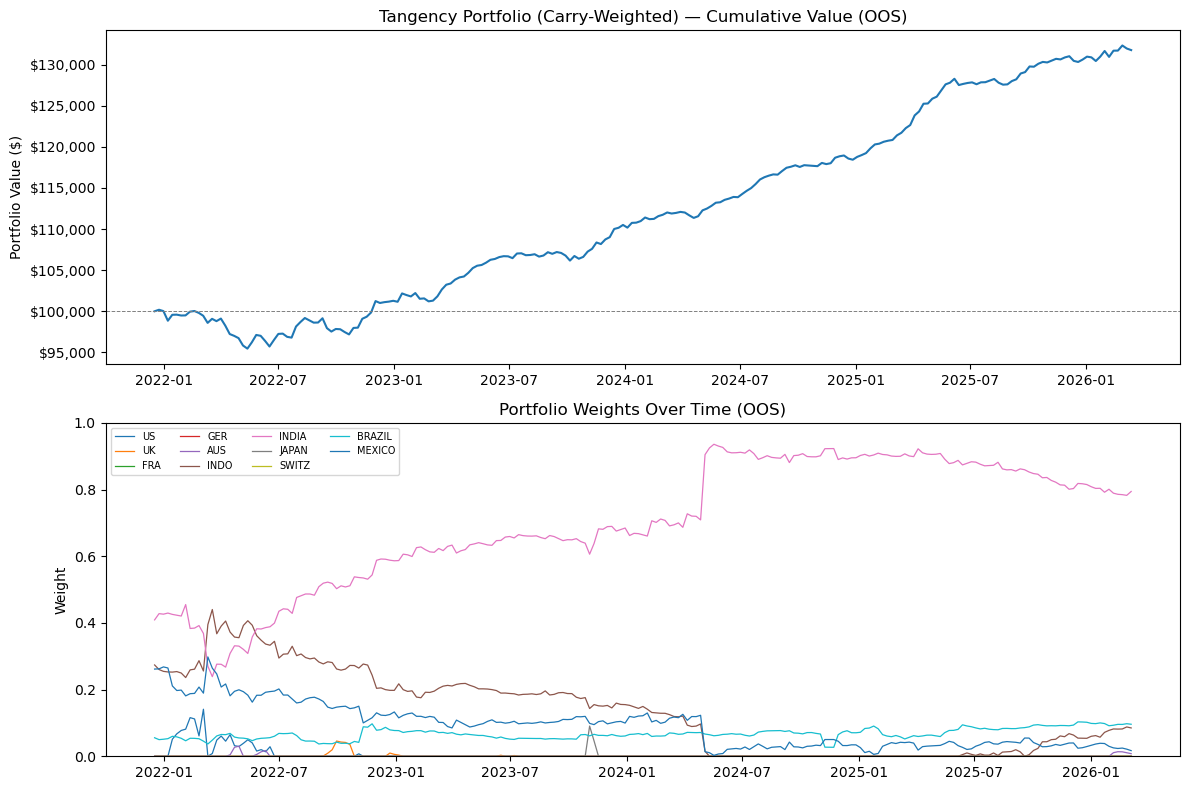

In [35]:
# plots
w_oos = weights_df.loc[split_date:].dropna(how='all').astype(float)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(port_oos.index, port_oos.values, lw=1.5)
axes[0].axhline(port_oos.iloc[0], color='grey', ls='--', lw=0.7)
axes[0].set_title("Tangency Portfolio (Carry-Weighted) — Cumulative Value (OOS)")
axes[0].set_ylabel("Portfolio Value ($)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for col in countries:
    axes[1].plot(w_oos.index, w_oos[col], lw=0.9, label=col)
axes[1].set_ylim(0, 1)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_title("Portfolio Weights Over Time (OOS)")
axes[1].set_ylabel("Weight")
axes[1].legend(ncol=4, fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()